In [1]:
import sys
import os
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
import torch
from accelerate.test_utils.testing import get_backend
from core.models import LinearRegression
from core.callbacks import WandBCallback
from lightning.pytorch.loggers import WandbLogger
from lightning import Trainer
from core.data import FullBatchDataModule
from core.estimators import BiasWithMSE
from core.utils import compute_Q_matrix, compute_beta_closed_form
from lightning.pytorch.callbacks import EarlyStopping
device, n_devices, _ = get_backend()
import matplotlib.pyplot as plt
plt.style.use("../clean_fig.mplstyle")
# device = "cpu"
# n_devices = 1

torch.set_float32_matmul_precision("highest")

## Ali et al. Linear Regression

In [5]:
# set seed ensure reproducibility
torch.manual_seed(56)
# deterministic behavior
torch.use_deterministic_algorithms(False)

p = 10 # input dimension / number of features
N = 1000 # number of samples
X = torch.randn(N, p)
# X = torch.diag(torch.randn(p))
betas = 3 * torch.randn(p)
y = X @ betas
dm_linear = FullBatchDataModule(X, y, num_workers=3)

In [6]:
eps = 1e-2
linear_model = LinearRegression(input_dim=p, 
                                output_dim=1, 
                                lr=eps/2, # fix mismatched learning rate due to 1/2 factor in the loss (not in torch)
                                fit_intercept=False, init_zeros=True)
wandb_logger = WandbLogger(
    project="inductive-bias", name="linear-regression", log_model=False,
    save_dir='../logs/'
)

lm_trainer = Trainer(
    max_epochs=500,
    accumulate_grad_batches=1,
    log_every_n_steps=1,
    logger=wandb_logger,
    callbacks=[
        WandBCallback(),
        EarlyStopping(monitor="train/loss", patience=5, mode="min"),
    ],
    accelerator=device,
    devices=n_devices,
)
lm_trainer.fit(linear_model, dm_linear)

/shared_data0/anon/.cache/pypoetry/virtualenvs/inductive-bias-v8JhmPLZ-py3.12/lib/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /shared_data0/anon/.cache/pypoetry/virtualenvs/i ...
Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/shared_data0/anon/.cache/pypoetry/virtualenvs/inductive-bias-v8JhmPLZ-py3.12/lib/python3.12/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
You are using a CUDA device ('NVIDIA L40S') that has Tensor Cores. To properly utilize the

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type    | Params | Mode 
----------------------------------------------
0 | linear    | Linear  | 10     | train
1 | loss_func | MSELoss | 0      | train
----------------------------------------------
10        Trainable params
0         Non-trainable params
10        Total params
0.000     Total estimated model params size (MB)
2         Modules in train mode
0         Modules in eval mode


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=500` reached.


epoch,▁▁▂▂▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇██
train/loss,█▇▆▆▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
trainer/global_step,▁▁▁▁▁▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇████
epoch,499
train/loss,0.00316
trainer/global_step,499


In [7]:
k = lm_trainer.current_epoch
# Compute beta iterates up to k
beta_iterates = [torch.zeros(p)]  # Initialize with beta_0
for i in range(1, k + 1):
    beta_prev = beta_iterates[-1]
    # beta_next = beta_prev + 2 * eps * (X.T @ y - X.T @ X @ beta_prev) / N # depends on the learning rate
    beta_next = beta_prev + eps * (X.T @ y - X.T @ X @ beta_prev) / N
    beta_iterates.append(beta_next)
    # print(f"Beta at step {i}: {beta_iterates[-1]}")
    
model_beta = linear_model.linear.weight.detach()
print(f"Final beta iterate: {beta_iterates[-1]}")
print(f"Model beta: {model_beta}")
assert torch.allclose(beta_iterates[-1], model_beta, atol=1e-5), "Final beta does not match the model's weight"

Final beta iterate: tensor([ 0.8831,  0.3626,  0.2703,  0.2992, -1.1959, -1.5158,  3.1080,  6.0013,
        -0.4549, -0.4155])
Model beta: tensor([[ 0.8831,  0.3626,  0.2703,  0.2992, -1.1959, -1.5158,  3.1080,  6.0013,
         -0.4549, -0.4155]])


In [8]:
# see if close to the true beta (will not be exact because of noise)
print(list(linear_model.parameters()))
print(betas)
assert torch.allclose(betas, linear_model.linear.weight[0], atol=1e-1)


[Parameter containing:
tensor([[ 0.8831,  0.3626,  0.2703,  0.2992, -1.1959, -1.5158,  3.1080,  6.0013,
         -0.4549, -0.4155]], requires_grad=True)]
tensor([ 0.8902,  0.3665,  0.2820,  0.3181, -1.2177, -1.5383,  3.1239,  6.0392,
        -0.4617, -0.4277])


In [9]:
k = lm_trainer.current_epoch
print(f"epoch: {k}")

Q = compute_Q_matrix(X, k, eps)
print(Q)

epoch: 500
tensor([[ 7.8866e-03, -6.4138e-04,  1.0844e-04, -6.2571e-04, -1.6834e-04,
          4.7756e-04,  7.7518e-04, -1.6919e-04, -3.1924e-04,  9.4949e-04],
        [-6.4138e-04,  1.0357e-02, -1.1893e-03,  8.7888e-04, -1.4690e-03,
         -9.1071e-04, -1.7522e-04, -5.4556e-04,  3.1225e-05, -1.1066e-03],
        [ 1.0844e-04, -1.1893e-03,  7.8898e-03,  5.6055e-04, -1.0847e-03,
         -5.4428e-04, -1.9049e-04,  8.4068e-04,  1.6749e-04, -1.1191e-03],
        [-6.2572e-04,  8.7888e-04,  5.6055e-04,  5.6981e-03, -1.8992e-03,
         -5.5867e-04,  6.4765e-05,  1.5856e-03,  1.8552e-04, -1.9065e-03],
        [-1.6834e-04, -1.4690e-03, -1.0847e-03, -1.8992e-03,  8.2854e-03,
          7.7157e-04, -9.4802e-04, -2.1311e-04, -1.4887e-04,  2.1908e-03],
        [ 4.7756e-04, -9.1071e-04, -5.4428e-04, -5.5867e-04,  7.7157e-04,
          7.8899e-03,  4.1221e-04, -1.2656e-03,  9.1137e-04, -7.5505e-04],
        [ 7.7518e-04, -1.7522e-04, -1.9049e-04,  6.4765e-05, -9.4802e-04,
          4.1221e-04,

In [10]:
beta_closed_form = compute_beta_closed_form(X, y, Q)
# Compare with model's beta
print(f"Closed-form solution: {str(beta_closed_form.detach().numpy())}")
print(f"Model beta: {str(model_beta[0].detach().numpy())}")

Closed-form solution: [ 0.8830989   0.36257637  0.27028227  0.29918322 -1.1958663  -1.5157784
  3.1079667   6.0013146  -0.45491147 -0.41551927]
Model beta: [ 0.8830991   0.3625759   0.27028227  0.2991831  -1.1958665  -1.5157783
  3.107966    6.001314   -0.4549117  -0.41551864]


In [11]:
from core.estimators import BiasWithMSE, BiasWithAutodiffLoss
from core.bias import MatrixRidgeBias, DiagMatrixRidgeBias, RidgeBias

torch.manual_seed(56)
# noisy_Q_init = Q.clone() + 0.1 * torch.randn(Q.shape[0], Q.shape[1])
# matrix_bias_model = MatrixRidgeBias(dim=p, Q_init=noisy_Q_init.clone())

matrix_bias_model = DiagMatrixRidgeBias(dim=p)
# matrix_bias_model = RidgeBias()
wandb_logger = WandbLogger(
    project="inductive-bias", name="matrix-ridge-bias", log_model=False
)

estimator = BiasWithMSE(
    predictive_model=linear_model,
    # predictive_loss_fn=torch.nn.functional.mse_loss,
    bias_model=matrix_bias_model,
    grad_match_loss_fn=torch.nn.functional.mse_loss,
    lr=1e-2,
    optimizer_cls=torch.optim.Adam,
)

trainer = Trainer(
    max_epochs=5000,
    accumulate_grad_batches=1,
    log_every_n_steps=1,
    logger=wandb_logger,
    callbacks=[
        WandBCallback(),
        EarlyStopping(monitor="train/loss", patience=150, mode="min"),
    ],
    accelerator=device,
    devices=n_devices,
)
trainer.fit(estimator, dm_linear)

# Q_hat = torch.eye(p) * estimator.bias_model.beta.detach()
Q_hat = torch.diag(estimator.bias_model.Q.detach())

# minibatch_dataloader = torch.utils.data.DataLoader(TensorDataset(X, y), batch_size=N//2, shuffle=True)
# trainer.fit(estimator, train_dataloaders=minibatch_dataloader)

/shared_data0/anon/.cache/pypoetry/virtualenvs/inductive-bias-v8JhmPLZ-py3.12/lib/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /shared_data0/anon/.cache/pypoetry/virtualenvs/i ...
Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name             | Type                | Params | Mode 
-----------------------------------------------------------------
0 | predictive_model | LinearRegression    | 10     | train
1 | bias_model       | DiagMatrixRidgeBias | 10     | train
-----------------------------------------------------------------
20        Trainable params
0         Non-trainable params
20        Total params
0.000     Total estimated model params size (MB)
4         Modules in train mode
0         Modules in eval mode


Training: |          | 0/? [00:00<?, ?it/s]

bias/Q,█▁▁▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
bias/Q_grad,█▇▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,▁▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▇▇▇▇▇▇████
train/loss,█▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
trainer/global_step,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▄▄▄▄▅▅▆▆▆▆▆▇▇▇▇▇▇██
bias/Q,0.06994
bias/Q_grad,0.0
epoch,600
train/loss,0.0
trainer/global_step,600


In [12]:
evals = torch.linalg.eigvalsh(Q)
print(f"Eigenvalues of Q: {evals}")
print(f"max eigenvalue: {evals.max()}")
print(f"min eigenvalue: {evals.min()}")

Eigenvalues of Q: tensor([0.0033, 0.0041, 0.0056, 0.0059, 0.0064, 0.0072, 0.0083, 0.0102, 0.0109,
        0.0143])
max eigenvalue: 0.014254487119615078
min eigenvalue: 0.0033099607098847628


In [13]:
# print("initial:\t", torch.diag(noisy_Q_init))
print("estimated:\n", Q_hat)
print("theoretical:\n", Q)

estimated:
 tensor([[0.0081, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0080, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0330, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0507, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0148, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0129, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0052, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0062, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0130,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0219]

In [14]:
print("estimated:", compute_beta_closed_form(X, y, Q_hat))
print("theoretical:", compute_beta_closed_form(X, y, Q))
print("ground truth:", linear_model.linear.weight[0].detach().numpy().round(5))

estimated: tensor([ 0.8831,  0.3626,  0.2703,  0.2992, -1.1959, -1.5158,  3.1080,  6.0013,
        -0.4549, -0.4155])
theoretical: tensor([ 0.8831,  0.3626,  0.2703,  0.2992, -1.1959, -1.5158,  3.1080,  6.0013,
        -0.4549, -0.4155])
ground truth: [ 0.8831   0.36258  0.27028  0.29918 -1.19587 -1.51578  3.10797  6.00131
 -0.45491 -0.41552]


### Visualization

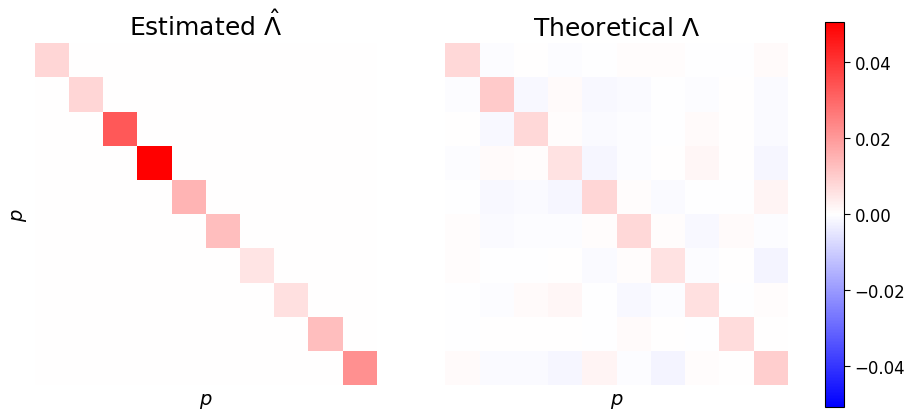

In [15]:
import seaborn as sns
# Prepare data on CPU and shared color scale
Q_cpu = Q.detach().cpu()
Qhat_cpu = Q_hat.detach().cpu()
vmax = max(Q_cpu.abs().max().item(), Qhat_cpu.abs().max().item())
vmin = -vmax

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# shared color scale, centered at zero
norm = plt.Normalize(vmin=vmin, vmax=vmax)
sns.heatmap(Qhat_cpu.numpy(), ax=axes[0], cmap="bwr", norm=norm, square=True, cbar=False,
            xticklabels=False, yticklabels=False)
axes[0].set_title(r"Estimated $\hat{\Lambda}$")
axes[0].set_xlabel(r"$p$")
axes[0].set_ylabel(r"$p$")

sns.heatmap(Q_cpu.numpy(), ax=axes[1], cmap="bwr", norm=norm, square=True, cbar=False,
            xticklabels=False, yticklabels=False)
axes[1].set_title(r"Theoretical $\Lambda$")
axes[1].set_xlabel(r"$p$")
axes[1].set_ylabel("")

# remove ticks and tick labels
for ax in axes:
    ax.tick_params(axis='both', which='both', bottom=False, left=False, labelbottom=False, labelleft=False)

# add one shared colorbar for both heatmaps
sm = plt.cm.ScalarMappable(cmap="bwr", norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=axes, location="right", pad=0.04)
plt.savefig("Lambda_comparison-ols.pdf")

In [25]:
# visualize the learned weights
from copy import deepcopy
theta_real = deepcopy(betas.numpy().round(5))
theta_hat = deepcopy(linear_model.linear.weight[0].detach().numpy().round(5))
theta_hat_prime = deepcopy(compute_beta_closed_form(X, y, Q_hat).detach().numpy().round(5))

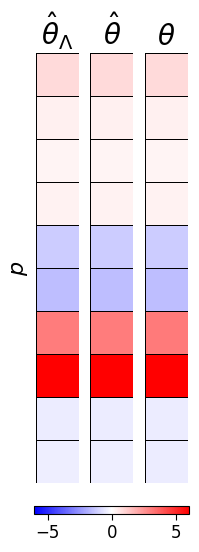

In [13]:
# TODO: make parallel vertical heatmaps of each weight vector theta
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
vmax = max(np.abs(theta_real).max(), np.abs(theta_hat).max(), np.abs(theta_hat_prime).max())
norm = plt.Normalize(vmin=-vmax, vmax=vmax)

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(2, 6))
axes = axes.flatten()
for ax, theta, title in zip(axes, 
                              [theta_hat_prime, theta_hat, theta_real], 
                              [r"$\hat{\theta}_{\Lambda}$", r"$\hat{\theta}$", r"$\theta$"]):
    sns.heatmap(theta.reshape(-1, 1), cmap="bwr", norm=norm, square=True, cbar=False,
                yticklabels=False, xticklabels=False, ax=ax, linewidths=0.5, linecolor='k')
    ax.set_title(title, fontsize=20)
    # ax.set_xlabel(r"$1$")
# set outer label only
axes[0].set_ylabel(r"$p$", fontsize=16)

# colorbar below
sm = plt.cm.ScalarMappable(cmap="bwr", norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=axes, orientation="horizontal", fraction=0.02, pad=0.05)

# plt.tight_layout()
plt.savefig("predictive_weights_comparison_ols.pdf")

In [50]:
np.save("theta_real_ols.npy", theta_real)
np.save("theta_hat_ols.npy", theta_hat)
np.save("theta_hat_prime_ols.npy", theta_hat_prime)

np.save("ols_Lambda_theory.npy", Q.cpu().numpy())
np.save("ols_Lambda_estimated.npy", Q_hat.cpu().numpy())

In [2]:
import numpy as np
theta_real = np.load("theta_real_ols.npy")
theta_hat = np.load("theta_hat_ols.npy")
theta_hat_prime = np.load("theta_hat_prime_ols.npy")
Q = np.load("ols_Lambda_theory.npy")
Q_hat = np.load("ols_Lambda_estimated.npy")

## How good are heuristics?

If we only fit the scalar $\lambda$ penalty term (which we know is not fully descriptive of the bias), does it still
give us a useful estimate of the bias?
i.e. theory tellls us $\lambda$ should decrease as k increases, is this true in practice?
 

In [ ]:
# set seed ensure reproducibility
torch.manual_seed(56)
# deterministic behavior
torch.use_deterministic_algorithms(False)

p = 5 # input dimension / number of features
N = 1000 # number of samples
X = torch.randn(N, p)
# X = torch.diag(torch.randn(p))
betas = 3 * torch.randn(p)
y = X @ betas
dm_linear = FullBatchDataModule(X, y, num_workers=3)

eps = 1e-2
linear_model = LinearRegression(input_dim=p, 
                                output_dim=1, 
                                lr=eps/2, # fix mismatched learning rate due to 1/2 factor in the loss (not in torch)
                                fit_intercept=False, init_zeros=True)
wandb_logger = WandbLogger(
    project="inductive-bias", name="linear-regression", log_model=False
)

lm_trainer = Trainer(
    max_epochs=500,
    accumulate_grad_batches=1,
    log_every_n_steps=1,
    logger=wandb_logger,
    callbacks=[
        WandBCallback(),
        EarlyStopping(monitor="train/loss", patience=5, mode="min"),
    ],
    accelerator=device,
    devices=n_devices,
)
lm_trainer.fit(linear_model, dm_linear)

In [ ]:
from core.estimators import BiasWithMSE, BiasWithAutodiffLoss
from core.bias import MatrixRidgeBias, DiagMatrixRidgeBias, RidgeBias

torch.manual_seed(56)

bias_model = RidgeBias()
wandb_logger = WandbLogger(
    project="inductive-bias", name="matrix-ridge-bias", log_model=False
)

estimator = BiasWithAutodiffLoss(
    predictive_model=linear_model,
    predictive_loss_fn=torch.nn.functional.mse_loss,
    bias_model=bias_model,
    grad_match_loss_fn=torch.nn.functional.mse_loss,
    lr=1e-2,
    optimizer_cls=torch.optim.Adam,
)

trainer = Trainer(
    max_epochs=5000,
    accumulate_grad_batches=1,
    log_every_n_steps=1,
    logger=wandb_logger,
    callbacks=[
        WandBCallback(),
        EarlyStopping(monitor="train/loss", patience=150, mode="min"),
    ],
    accelerator=device,
    devices=n_devices,
)
trainer.fit(estimator, dm_linear)

/shared_data0/anon/.cache/pypoetry/virtualenvs/inductive-bias-v8JhmPLZ-py3.12/lib/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /shared_data0/anon/.cache/pypoetry/virtualenvs/i ...
Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name             | Type             | Params | Mode 
--------------------------------------------------------------
0 | predictive_model | LinearRegression | 5      | train
1 | bias_model       | RidgeBias        | 1      | train
--------------------------------------------------------------
6         Trainable params
0         Non-trainable params
6         Total params
0.000     Total estimated model params size (MB)
4         Modules in train mode
0         Modules in eval mode


Training: |          | 0/? [00:00<?, ?it/s]

bias/beta,█▇▅▅▅▄▄▄▃▃▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,▁▁▁▂▂▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▄▄▄▅▅▅▆▆▆▇▇▇█████
train/loss,█▇▇▄▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
trainer/global_step,▁▁▁▁▁▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇██
bias/beta,1e-05
epoch,601
train/loss,0.0
trainer/global_step,601


In [12]:
bias_model.beta

Parameter containing:
tensor([6.8130e-06], requires_grad=True)

10 epochs: $\lambda = 0.00946$

50 epochs: $\lambda = 0.00153$

150 epochs: $\lambda = 0.00028$